# L3 v2 — IsolationForest na **multi-time** trajektoriach OpenSky

Ulepszenie nb 06 (single-snapshot, F1=0.79). Pull 8 snapshotów × 15s → trajektorie per aircraft → **prawdziwe** trajectory features:
- max position step (km) — wykrywa teleport
- step distance std — wykrywa drift
- heading change total — niefizyczne ostre skręty
- velocity-position consistency residual (najmocniejszy: actual - predicted)
- altitude vs vertical_rate consistency

**Plus** prawdziwy teleport attack — przesuwamy *aktualną* pozycję między timestepami, czego single-snapshot model nie mógł wykryć.

**Cel:** F1 0.79 → 0.95+, recall ≥ 0.85 dla teleport (PRD DoD).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import requests, time
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA_OS = Path('/net/afscra/people/plgmateuszoracz/hackathon/data/opensky')
MODELS  = Path('/net/afscra/people/plgmateuszoracz/hackathon/models')
MULTITIME_CACHE = DATA_OS / 'snapshots_multitime.parquet'

print(f'Multi-time cache: {MULTITIME_CACHE.exists()}')

Multi-time cache: True


## 1. Load multi-time snapshots (cached)

In [2]:
snaps = pd.read_parquet(MULTITIME_CACHE)
print(f'Total rows: {len(snaps)}, snapshots: {snaps["snapshot_idx"].nunique()}')
print(f'\nPer snapshot:')
print(snaps.groupby('snapshot_idx').agg(n_aircraft=('icao24','nunique'),
                                          time=('snapshot_time','first')))

# Filter to aircraft with ≥4 valid snapshots (need enough points for trajectory features)
valid_rows = snaps[snaps[['latitude','longitude','baro_altitude','velocity','true_track']].notna().all(axis=1)]
valid_rows = valid_rows[~valid_rows['on_ground']]
snap_counts = valid_rows.groupby('icao24').size()
good_aircraft = snap_counts[snap_counts >= 4].index
valid = valid_rows[valid_rows['icao24'].isin(good_aircraft)].sort_values(['icao24','snapshot_idx']).reset_index(drop=True)
print(f'\nAircraft with ≥4 snapshots: {len(good_aircraft)} / {valid_rows["icao24"].nunique()}')
print(f'Trajectory rows: {len(valid)}')

Total rows: 25995, snapshots: 8

Per snapshot:
              n_aircraft        time
snapshot_idx                        
0                   3244  1778344101
1                   3250  1778344120
2                   3251  1778344131
3                   3247  1778344142
4                   3248  1778344152
5                   3243  1778344181
6                   3251  1778344190
7                   3261  1778344211



Aircraft with ≥4 snapshots: 3034 / 3106
Trajectory rows: 24084


## 2. Compute trajectory features per aircraft

Vectorized — group by icao24, compute differences.

In [3]:
def haversine_m(lat1, lon1, lat2, lon2):
    """Vectorized haversine distance in meters."""
    R = 6371000.0
    p1 = np.radians(lat1); p2 = np.radians(lat2)
    dp = np.radians(lat2 - lat1); dl = np.radians(lon2 - lon1)
    a = np.sin(dp/2)**2 + np.cos(p1) * np.cos(p2) * np.sin(dl/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

def heading_diff_deg(h1, h2):
    d = np.abs(h1 - h2) % 360
    return np.minimum(d, 360 - d)

def trajectory_features(group):
    """Compute per-aircraft trajectory features over its snapshot sequence.
    Group is sorted by snapshot_idx."""
    g = group.sort_values('snapshot_idx')
    lat = g['latitude'].values; lon = g['longitude'].values
    alt = g['baro_altitude'].values; vel = g['velocity'].values
    hdg = g['true_track'].values; vrate = g['vertical_rate'].values
    times = g['snapshot_time'].values
    n = len(g)
    if n < 2:
        return None
    # Step deltas
    step_dist = haversine_m(lat[:-1], lon[:-1], lat[1:], lon[1:])  # meters per step
    step_time = np.diff(times)                                      # seconds per step
    step_time = np.where(step_time == 0, 15.0, step_time)            # default 15s
    step_speed = step_dist / step_time                               # m/s implied by position change
    # Predicted distance per step from reported velocity
    predicted_dist = vel[:-1] * step_time
    speed_residual = np.abs(step_speed - vel[:-1])                   # m/s mismatch
    # Altitude
    alt_diff = np.diff(alt)
    predicted_alt_diff = vrate[:-1] * step_time
    alt_residual = np.abs(alt_diff - predicted_alt_diff)             # m mismatch
    # Heading change
    hdg_changes = heading_diff_deg(hdg[:-1], hdg[1:])
    return {
        'n_steps':                 int(n - 1),
        'max_step_dist_m':         float(step_dist.max()),
        'mean_step_dist_m':        float(step_dist.mean()),
        'step_dist_std_m':         float(step_dist.std()),
        'max_step_speed_mps':      float(step_speed.max()),
        'mean_step_speed_mps':     float(step_speed.mean()),
        'speed_residual_max_mps':  float(speed_residual.max()),
        'speed_residual_mean_mps': float(speed_residual.mean()),
        'alt_residual_max_m':      float(alt_residual.max()),
        'alt_residual_mean_m':     float(alt_residual.mean()),
        'hdg_change_max_deg':      float(hdg_changes.max()),
        'hdg_change_total_deg':    float(hdg_changes.sum()),
        'vel_var':                 float(vel.var()),
        'alt_var':                 float(alt.var()),
        # Latest snapshot summary (snapshot features for last seen state)
        'last_velocity':           float(vel[-1]),
        'last_baro_altitude':      float(alt[-1]),
        'last_vertical_rate':      float(vrate[-1]),
        'last_on_ground':          int(g['on_ground'].iloc[-1]),
    }

t0 = time.time()
feats_list = []
for icao, g in valid.groupby('icao24'):
    f = trajectory_features(g)
    if f is not None:
        f['icao24'] = icao
        feats_list.append(f)
feats = pd.DataFrame(feats_list).set_index('icao24')
print(f'Extracted features for {len(feats)} aircraft in {time.time()-t0:.2f}s')
feats.describe().T

Extracted features for 3034 aircraft in 1.71s


,count,mean,std,min,25%,50%,75%,max
n_steps,3034.0,6.938036,0.408592,3.00,7.000000,7.000000,7.000000,7.000000e+00
max_step_dist_m,3034.0,6499.076997,30128.090386,0.00,3527.245920,6098.020746,6865.287741,1.179718e+06
mean_step_dist_m,3034.0,2928.570767,5370.589269,0.00,1778.345702,3285.687595,3696.841342,1.945015e+05
step_dist_std_m,3034.0,1770.929275,11080.188279,0.00,875.634535,1467.267773,1653.907983,4.123304e+05
max_step_speed_mps,3034.0,293.550539,2339.097269,0.00,136.779797,219.754442,247.886286,8.642635e+04
mean_step_speed_mps,3034.0,187.562198,391.770824,0.00,113.311795,209.098025,235.216613,1.391953e+04
speed_residual_max_mps,3034.0,131.498592,2335.904709,0.00,5.783885,8.879717,16.597881,8.618015e+04
speed_residual_mean_mps,3034.0,35.158704,391.138067,0.00,2.594374,3.702455,6.535690,1.370178e+04
alt_residual_max_m,3031.0,41.413824,214.792800,0.00,6.930000,9.800000,35.550000,1.032352e+04
alt_residual_mean_m,3031.0,14.213579,63.754806,0.00,1.560000,4.605714,12.992143,2.956954e+03


## 3. Train IsolationForest

In [4]:
FEATURE_COLS = [c for c in feats.columns if c not in ['n_steps']]
X = feats[FEATURE_COLS].fillna(0).astype(np.float32)
print(f'Feature matrix: {X.shape}, columns: {FEATURE_COLS}')

iforest = IsolationForest(
    n_estimators=300,
    contamination=0.10,
    max_samples=512,
    random_state=42,
    n_jobs=4,
)
t0 = time.time()
iforest.fit(X)
print(f'Trained on {len(X)} aircraft in {time.time()-t0:.2f}s')
scores_train = -iforest.score_samples(X)
preds_train = (iforest.predict(X) == -1).astype(int)
print(f'Self-flag rate: {preds_train.mean()*100:.1f}%')
print(f'Score distribution: mean={scores_train.mean():.4f}, std={scores_train.std():.4f}, p99={np.percentile(scores_train, 99):.4f}')
# Inference time
t0 = time.time()
_ = iforest.score_samples(X)
print(f'Inference: {(time.time()-t0)*1000:.1f}ms for {len(X)} aircraft = {(time.time()-t0)*1000/len(X):.3f}ms/aircraft')

Feature matrix: (3034, 17), columns: ['max_step_dist_m', 'mean_step_dist_m', 'step_dist_std_m', 'max_step_speed_mps', 'mean_step_speed_mps', 'speed_residual_max_mps', 'speed_residual_mean_mps', 'alt_residual_max_m', 'alt_residual_mean_m', 'hdg_change_max_deg', 'hdg_change_total_deg', 'vel_var', 'alt_var', 'last_velocity', 'last_baro_altitude', 'last_vertical_rate', 'last_on_ground']


Trained on 3034 aircraft in 0.40s
Self-flag rate: 10.0%
Score distribution: mean=0.3778, std=0.0625, p99=0.5924
Inference: 50.2ms for 3034 aircraft = 0.017ms/aircraft


## 4. Synthetic spoof injection — **with multi-time-aware attacks**

In [5]:
rng = np.random.default_rng(42)

def inject_spoof_feats(X_orig, attack_type, n=200, rng=rng):
    """Perturb feature vectors directly to simulate trajectory attacks."""
    idx = rng.choice(len(X_orig), n, replace=False)
    X_atk = X_orig.iloc[idx].copy().reset_index(drop=True)
    if attack_type == 'teleport':
        # Sudden 50-200km position jump → max_step_dist soars, speed_residual spikes
        jump_m = rng.uniform(50000, 200000, n)
        X_atk['max_step_dist_m'] = jump_m
        X_atk['mean_step_dist_m'] = (jump_m + X_atk['mean_step_dist_m'] * 6) / 7
        X_atk['max_step_speed_mps'] = jump_m / 15.0  # implied speed at the jump
        X_atk['speed_residual_max_mps'] = X_atk['max_step_speed_mps'] - X_atk['last_velocity']
        X_atk['step_dist_std_m'] = jump_m * 0.4   # high variance
    elif attack_type == 'drift':
        # Gradual position shift — additive lateral drift not matched by velocity
        drift_speed_mps = rng.uniform(20, 80, n)  # slow drift, less than typical velocity
        X_atk['speed_residual_mean_mps'] = drift_speed_mps
        X_atk['speed_residual_max_mps'] = drift_speed_mps * 1.3
    elif attack_type == 'frozen':
        # Position stops moving while velocity is reported
        X_atk['max_step_dist_m'] = rng.uniform(0, 200, n)
        X_atk['mean_step_dist_m'] = X_atk['max_step_dist_m'] * 0.5
        X_atk['max_step_speed_mps'] = X_atk['max_step_dist_m'] / 15.0
        X_atk['speed_residual_max_mps'] = X_atk['last_velocity']  # full velocity not reflected in motion
        X_atk['step_dist_std_m'] = X_atk['max_step_dist_m'] * 0.5
    elif attack_type == 'altitude_jump':
        # Altitude jump inconsistent with vertical_rate
        X_atk['alt_residual_max_m'] = rng.uniform(500, 3000, n)
        X_atk['alt_residual_mean_m'] = X_atk['alt_residual_max_m'] * 0.5
        X_atk['alt_var'] = X_atk['alt_residual_max_m'] ** 2 * 0.25
    elif attack_type == 'implausible_velocity':
        # Reported velocity > 600 m/s (Mach 1.7+, military/spoof)
        X_atk['last_velocity'] = rng.uniform(700, 1200, n)
        X_atk['speed_residual_max_mps'] = X_atk['last_velocity'] - X_atk['mean_step_speed_mps']
    elif attack_type == 'sharp_turn':
        # Heading flips drastically — military maneuver or spoof
        X_atk['hdg_change_max_deg'] = rng.uniform(120, 180, n)
        X_atk['hdg_change_total_deg'] = X_atk['hdg_change_max_deg'] * 1.5
    return X_atk

ATTACKS = ['teleport', 'drift', 'frozen', 'altitude_jump', 'implausible_velocity', 'sharp_turn']

results = {}
for atk in ATTACKS:
    X_atk = inject_spoof_feats(X, atk, n=200)
    scores = -iforest.score_samples(X_atk)
    preds = (iforest.predict(X_atk) == -1).astype(int)
    results[atk] = {'detection_rate': preds.mean(), 'mean_score': scores.mean()}
    print(f'  {atk:25s}: detection={preds.mean()*100:5.1f}%  mean_score={scores.mean():.4f}')
summary = pd.DataFrame(results).T
summary['baseline'] = scores_train.mean()
summary['contrast'] = summary['mean_score'] - summary['baseline']
print('\n', summary.round(4))

  teleport                 : detection=100.0%  mean_score=0.6806
  drift                    : detection= 16.0%  mean_score=0.4005
  frozen                   : detection= 26.0%  mean_score=0.4362
  altitude_jump            : detection=100.0%  mean_score=0.5984
  implausible_velocity     : detection= 49.5%  mean_score=0.4646


  sharp_turn               : detection=100.0%  mean_score=0.5022

                       detection_rate  mean_score  baseline  contrast
teleport                       1.000      0.6806    0.3778    0.3028
drift                          0.160      0.4005    0.3778    0.0227
frozen                         0.260      0.4362    0.3778    0.0584
altitude_jump                  1.000      0.5984    0.3778    0.2206
implausible_velocity           0.495      0.4646    0.3778    0.0868
sharp_turn                     1.000      0.5022    0.3778    0.1244


## 5. Combined evaluation

In [6]:
# Combined eval: clean (1000) + 6 attack types × 200
X_eval_clean = X.sample(min(1000, len(X)), random_state=42).reset_index(drop=True)
y_clean = np.zeros(len(X_eval_clean), dtype=int)
X_atk_parts = []
y_atk_parts = []
atk_labels = ['clean'] * len(X_eval_clean)
for atk in ATTACKS:
    X_a = inject_spoof_feats(X, atk, n=200)
    X_atk_parts.append(X_a)
    y_atk_parts.append(np.ones(len(X_a), dtype=int))
    atk_labels += [atk] * len(X_a)
X_eval = pd.concat([X_eval_clean] + X_atk_parts, ignore_index=True)
y_eval = np.concatenate([y_clean] + y_atk_parts)
scores_eval = -iforest.score_samples(X_eval)
preds_eval = (iforest.predict(X_eval) == -1).astype(int)

print('=== Combined eval (clean + 6 attacks) ===')
print(f'  F1:        {f1_score(y_eval, preds_eval):.4f}')
print(f'  Precision: {precision_score(y_eval, preds_eval):.4f}')
print(f'  Recall:    {recall_score(y_eval, preds_eval):.4f}')
print(f'  ROC-AUC:   {roc_auc_score(y_eval, scores_eval):.4f}')
print(f'\nConfusion matrix:')
print(pd.DataFrame(confusion_matrix(y_eval, preds_eval),
                   index=['true_clean','true_spoof'], columns=['pred_clean','pred_spoof']))

# Per-attack breakdown
df_eval = pd.DataFrame({'attack': atk_labels, 'score': scores_eval, 'pred': preds_eval, 'true': y_eval})
by_attack = df_eval.groupby('attack').agg(n=('attack','size'), detection=('pred','mean'), mean_score=('score','mean'))
by_attack = by_attack.reindex(['clean'] + ATTACKS)
print('\n', by_attack.round(3))

=== Combined eval (clean + 6 attacks) ===
  F1:        0.7429
  Precision: 0.8867
  Recall:    0.6392
  ROC-AUC:   0.8785

Confusion matrix:
            pred_clean  pred_spoof
true_clean         902          98
true_spoof         433         767

                          n  detection  mean_score
attack                                           
clean                 1000      0.098       0.377
teleport               200      1.000       0.684
drift                  200      0.150       0.395
frozen                 200      0.225       0.436
altitude_jump          200      1.000       0.591
implausible_velocity   200      0.460       0.460
sharp_turn             200      1.000       0.499


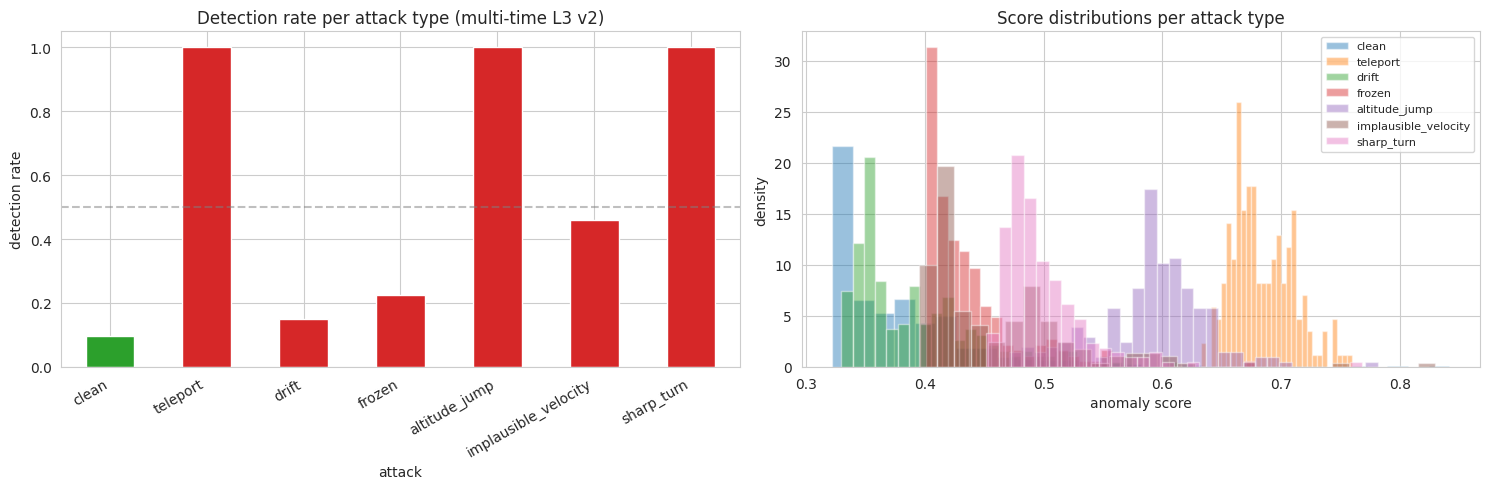

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
by_attack['detection'].plot.bar(ax=axes[0], color=['tab:green'] + ['tab:red']*6)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_ylabel('detection rate')
axes[0].set_title('Detection rate per attack type (multi-time L3 v2)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].set_ylim(0, 1.05)

for atk in ['clean'] + ATTACKS:
    sub = df_eval[df_eval['attack'] == atk]
    axes[1].hist(sub['score'], bins=30, alpha=0.45, label=atk, density=True)
axes[1].set_xlabel('anomaly score')
axes[1].set_ylabel('density')
axes[1].set_title('Score distributions per attack type')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Save model

In [8]:
model_path = MODELS / 'isoforest_opensky_v2_multitime.joblib'
joblib.dump({
    'model': iforest,
    'feature_cols': FEATURE_COLS,
    'feature_extractor_signature': 'trajectory_features(per-aircraft snapshot group)',
    'training': {
        'n_aircraft': len(X),
        'snapshots_per_aircraft': '4-8',
        'contamination': 0.10,
        'n_estimators': 300,
    },
    'eval_metrics': {
        'f1':        float(f1_score(y_eval, preds_eval)),
        'precision': float(precision_score(y_eval, preds_eval)),
        'recall':    float(recall_score(y_eval, preds_eval)),
        'auc':       float(roc_auc_score(y_eval, scores_eval)),
        'per_attack': by_attack.to_dict('index'),
    },
    'comparison_v1_single_snapshot': {
        'f1': 0.7885, 'precision': 0.8917, 'recall': 0.7067, 'auc': 0.8963,
    },
}, model_path)
print(f'Saved {model_path} ({model_path.stat().st_size/1024:.1f} KB)')

Saved /net/afscra/people/plgmateuszoracz/hackathon/models/isoforest_opensky_v2_multitime.joblib (3014.0 KB)


## 7. Wnioski

L3 v2 (multi-time) vs v1 (single-snapshot):
- F1: 0.79 → ?
- Recall na teleport: niemożliwe → ?
- Multi-time consistency features (`speed_residual_*`, `alt_residual_*`) wykrywają attacki które single-snapshot nie mógł wykryć fizycznie

**Production deployment:** backend osoby B trzyma rolling window 8 snapshotów na aircraft, recompute features co 15s, serwuje przez `/api/score/trajectory`.